In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

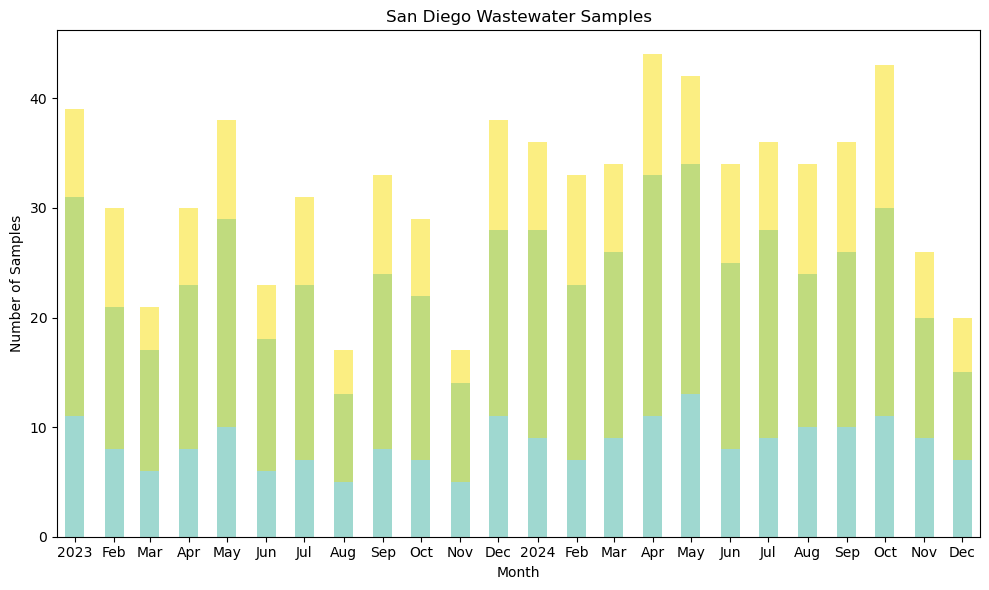

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

metadata = pd.read_csv('../data/search_metadata.csv')
metadata['collection_date'] = pd.to_datetime(metadata['collection_date'])
metadata = metadata[~metadata['sample'].str.contains('rerun|separate|combined', case=False, na=False)]
metadata = metadata.drop_duplicates(subset=['sample'])

metadata['month'] = metadata['collection_date'].dt.to_period('M').dt.to_timestamp()
location_monthly = metadata.groupby(['month', 'location']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#9FD8D0', '#C0DB7E', '#FBEE82']

bottom = None
for i, location in enumerate(location_monthly.columns):
    ax.bar(
        location_monthly.index,
        location_monthly[location],
        bottom=bottom,
        color=colors[i % len(colors)],
        label=location,
        width=15,
    )
    bottom = location_monthly[location] if bottom is None else bottom + location_monthly[location]

# Format date axis
ax.set(xlim=(location_monthly.index.min() - pd.Timedelta(14, unit='D'), location_monthly.index.max() + pd.Timedelta(14, unit='D')))
locator = mdates.MonthLocator(bymonthday=1)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

# Labels and style
plt.title('San Diego Wastewater Samples')
plt.xlabel('Month')
plt.ylabel('Number of Samples')
# plt.legend(title='Location', loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
plt.tight_layout()

# Save and show
plt.savefig('search_data.pdf', bbox_inches='tight', transparent=True)
plt.show()
